In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("data/credit_risk_dataset.csv")

df.head()

In [ ]:
df.info()
df.describe()

In [ ]:
df_clean = df.drop(columns=[
    "customer_id",
    "loan_default_history",
    "fraud_flag",
    "credit_score"
])

In [ ]:
df_clean = pd.get_dummies(df_clean, drop_first=True)

df_clean.head()

In [ ]:
X = df_clean.drop(columns=["credit_risk"])
y = df_clean["credit_risk"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.coef_[0]
})

feature_importance.sort_values(by="importance", ascending=False)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probs)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - MicroScore")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - MicroScore")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

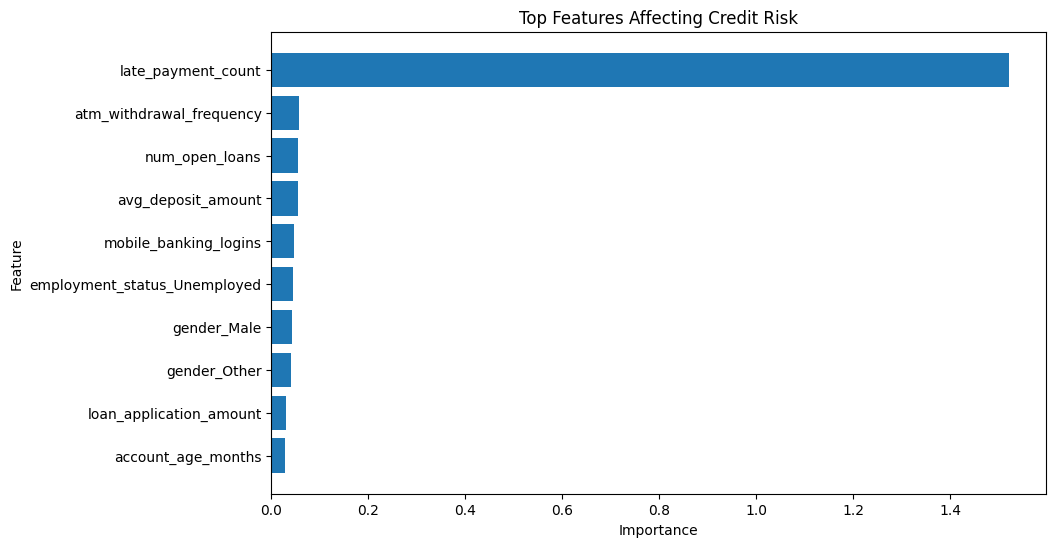

In [30]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top Features Affecting Credit Risk")

plt.gca().invert_yaxis()

plt.show()